In [202]:

import os
import pandas as pd
import numpy as np
import networkx as nx 
import matplotlib.pyplot as plt
import torch
from networkx.algorithms.community import greedy_modularity_communities, modularity
from scipy.stats import spearmanr, pearsonr
import seaborn as sns
from sklearn.decomposition import PCA
from node2vec import Node2Vec
from community import community_louvain

In [203]:
def clean_gt_file_names(importance_ranking):

    """ Gets torch files of ground truth and replaces any old twitter
        usernames with the new ones to match the df_data """

    # Load the DataFrame with member data
    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')

    # Fill NA values in 'new_twitter_name' with values from 'twitter_name'
    members['new_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    # Create a dictionary mapping from the old Twitter names to the new Twitter names
    name_mapping = dict(zip(members['twitter_name'], members['new_twitter_name']))

    # Initialize a new dictionary to hold the updated importance ranking
    updated_importance_ranking = {}

    # Update the dictionary keys
    for old_name, value in importance_ranking.items():
        # Get the new Twitter name if available, otherwise keep the old name
        new_name = name_mapping.get(old_name, old_name)
        updated_importance_ranking[new_name] = value

    # Assign the updated dictionary back to importance_ranking
    return updated_importance_ranking

# Print the updated importance ranking to check
# importance_ranking = torch.load('01_normalized_congress_member_to_affiliation_score.pth')


In [204]:
def assign_strength(df, inflection_point, party_flag):
    """ Assigns 'strong' or 'weak' based on the affiliation score. """
    if party_flag == 'R':
        return 'strong' if df['affiliation_score'] >= inflection_point else 'weak'
    else:  # 'D'
        return 'strong' if df['affiliation_score'] <= inflection_point else 'weak'

In [205]:
def build_bipartite_network(df_data):

    """ Builds directed network using politicians and their followings as nodes
    and directed edges based on if one node follows the other. Used for finding importance
    of websites to filter network """

    G = nx.DiGraph()

    # Add edges based on the politicians and the people they follow
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']
        following_list = row['following']  # List of people the politician follows
        
        # Add the politician as a node
        G.add_node(politician, party=row['party'])
        
        # Add edges for each person the politician follows
        for followee in following_list:
            G.add_node(followee)  # Add the followed account as a node
            G.add_edge(politician, followee)  # Directed edge from politician to followed account
    
    return G

In [206]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]
    
    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]
    importance_ranking = clean_gt_file_names(torch.load('01_normalized_username_to_affiliation_score.pth', weights_only=False))
    df_data['affiliation_score'] = df_data['current_twitter_name'].map(importance_ranking)
    # df_data['strength'] = df_data.apply(lambda x: assign_strength(x, 0.75 if x['party'] == 'R' else -0.75, x['party']), axis=1)

    return df_data, republican_df, democratic_df

In [207]:
def degree_lower_remover(df_data,G_bipartite, threshold=2):
    """ Removes nodes with degree lower than threshold from the bipartite graph """
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= threshold}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [208]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [209]:
def merge_n_communities_by_edge_count(G, communities, no_communities):
    """Merge a list of communities into exactly n_communities based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.
        no_communities (int): Desired number of communities after merging.

    Returns:
        list of set: Communities merged based on edge connectivity.
    """
    
    if len(communities) < no_communities:
        raise ValueError("The number of initial communities must be at least equal to the desired number of final communities.")

    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]

    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)

    # Start with the largest communities as determined by 'no_communities'
    largest_communities = communities[:no_communities]
    remaining_communities = communities[no_communities:]

    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into the largest based on edge counts
    for community in remaining_communities:
        max_edges = -1
        best_target_idx = -1

        # Determine which of the largest communities this should merge with
        for i, large_community in enumerate(largest_communities):
            edge_count = count_edges_between(community, large_community)
            if edge_count > max_edges:
                max_edges = edge_count
                best_target_idx = i

        # Merge the community into the best matching largest community
        largest_communities[best_target_idx].update(community)
    return largest_communities


In [210]:
# NEW VERSION CHECK IF WORKS AND THEN TRY IMPLEMENT THE OTHERS

def louvain_two_communities(G):

    """ Run the Louvain algorithm to detect communities """

    partition = community_louvain.best_partition(G)


    initial_communities = {}
    for node, community in partition.items():
        if community not in initial_communities:
            initial_communities[community] = set()
        initial_communities[community].add(node)

    # Convert dictionary of communities into a list of sets
    communities_list = list(initial_communities.values())
    print(len(communities_list))

    # Step 3: Merge communities into two based on edge connectivity
    if len(communities_list) > 2:
        # communities = merge_communities_by_edge_count(G, communities_list)
        communities = merge_n_communities_by_edge_count(G, communities_list, 2)
        # communities = merge_communities_max_modularity(G, communities_list)
        # communities = merge_into_two_communities(communities_list)
    else:
        communities = communities_list
    # Create the final two-community split
    node_to_community = {}
    for node in communities[0]:
        node_to_community[node] = 1
    for node in communities[1]:
        node_to_community[node] = 2

    # Calculate modularity value
    try:
        mod_value = modularity(G, communities)
    except:
        mod_value = 0

    return communities, mod_value

In [211]:
def political_alignment(G, communities):
    """
    Analyze alignment with political parties for a given set of communities.

    Args:
        G (networkx.Graph): The graph from which the communities are derived, with nodes having a 'party' attribute.
        communities (list of set): List of communities, where each community is a set of nodes.

    Returns:
        dict: Dictionary containing the political alignment of each community.
    """
    # Initialize an alignment dictionary for all communities
    alignment = {}
    for idx, community in enumerate(communities, start=1):
        # Initialize party counts for the current community
        alignment[idx] = {'R': 0, 'D': 0}
        for node in community:
            if 'party' in G.nodes[node]:  # Check if the 'party' attribute exists
                party = G.nodes[node]['party']
                if party in alignment[idx]:  # Increment the party count if it's either 'R' or 'D'
                    alignment[idx][party] += 1
                else:  # Optional: initialize other party labels dynamically
                    alignment[idx][party] = 1

    return alignment


In [212]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politician
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [213]:
def calculate_degree_ratio(node, graph, node_to_community):
    neighbors = list(graph.neighbors(node))
    if not neighbors:
        return 0  # Avoid division by zero if no neighbors
    # sign = 1 if graph.nodes[node]['party'] == 'R' else -1
    in_community = sum(1 for neighbor in neighbors if node_to_community.get(neighbor) == node_to_community.get(node))
    return in_community / len(neighbors)



In [214]:

def calculate_neighbour_degree_ratio(node, graph, node_to_community):
    # Get neighbors of the node
    neighbors = list(graph.neighbors(node))
    print(node, neighbors)
    if not neighbors:
        return 0  # Return 0 if there are no neighbors to avoid division by zero
    
    # Sum of degree ratios for neighbors in the same community
    same_community_sum = sum(graph.nodes[neighbor]['final_degree_ratio'] for neighbor in neighbors 
                             if node_to_community[neighbor] == node_to_community[node])
    
    # Sum of degree ratios for all neighbors
    total_sum = sum(graph.nodes[neighbor]['final_degree_ratio'] for neighbor in neighbors)
    
    # Calculate the ratio
    return same_community_sum / total_sum if total_sum != 0 else 0


In [215]:
num_nodes = -1
follow_thresh = 26

In [216]:
df_data, republican_df, democratic_df = read_data(num_nodes)
df_data

,current_twitter_name,party,complete_following,following,affiliation_score
1,SpeakerRyan,R,"[DarrellIssa, WaysandMeansGOP, cathymcmorris, ...","[DarrellIssa, WaysandMeansGOP, RepKevinBrady, ...",1.406593
2,SpeakerPelosi,D,"[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...","[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...",-1.479452
3,michelebachmann,R,"[DavidLimbaugh, RedState, Heritage, ScottWalke...","[DavidLimbaugh, RedState, Heritage, ScottWalke...",1.219780
4,dwstweets,D,"[donnabrazile, Eugene_Robinson, JaredEMoskowit...","[donnabrazile, Eugene_Robinson, JaredEMoskowit...",-1.479452
5,EricCantor,R,"[EWErickson, foxnewspolitics, SpeakerBoehner, ...","[EWErickson, foxnewspolitics, SpeakerBoehner, ...",1.340659
...,...,...,...,...,...
176,stabenow,D,"[SenStabenow, SenGaryPeters, gretchenwhitmer, ...","[SenStabenow, SenGaryPeters, gretchenwhitmer, ...",-1.164384
179,sen_joemanchin,D,"[SenatorSinema, lisamurkowski, WVGovernor, Sen...","[SenatorSinema, WVGovernor, SenCapito, SenJoni...",-1.041096
180,sendancoats,R,"[AttyAbdul, lisamurkowski, nkellyIN, marybschn...","[AttyAbdul, nkellyIN, marybschneider, camsavag...",1.010989
181,mcconnellpress,R,"[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...","[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...",0.912088


In [217]:
G_bipartite = build_bipartite_network(df_data)
degree_lower_remover(df_data, G_bipartite, threshold = 2)

In [218]:
G = build_network(df_data, follow_thresh, False, True)
communities, mod_value = louvain_two_communities(G)
node_to_community = {}
for node in communities[0]:
    node_to_community[node] = 1
for node in communities[1]:
    node_to_community[node] = 2


4


In [219]:
alignment = political_alignment(G, communities)
comm_labels = classify_communities(alignment)
print(comm_labels)
alignment

{1: 'Republican', 2: 'Democrat'}


{1: {'R': 87, 'D': 2}, 2: {'R': 4, 'D': 71}}

In [220]:
df_data_degrees20 = df_data.copy()
G_bipartite = build_bipartite_network(df_data)
degree_lower_remover(df_data_degrees20, G_bipartite, threshold = 20)
G_degrees20 = build_network(df_data_degrees20, 5, False, True)

In [221]:
# Create and fit model
node2vec = Node2Vec(G_degrees20, dimensions=64, walk_length=30, num_walks=200, workers=2)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Get embeddings as DataFrame
embedding_df = pd.DataFrame([model.wv[node] for node in G.nodes()], index=G.nodes())


Generating walks (CPU: 2): 100%|██████████| 100/100 [00:07<00:00, 12.60it/s]


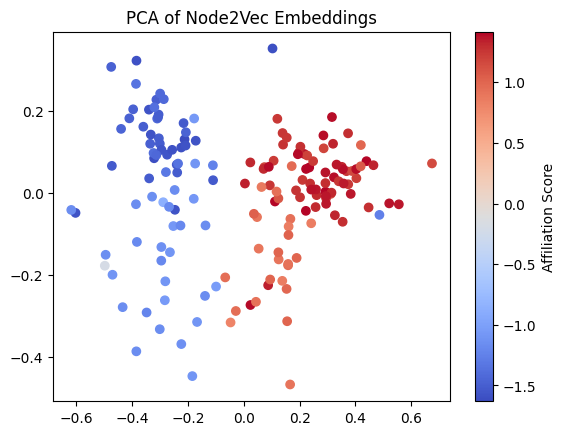

In [222]:


pca = PCA(n_components=2)
reduced = pca.fit_transform(embedding_df.values)

plt.scatter(reduced[:, 0], reduced[:, 1], c=df_data['affiliation_score'], cmap='coolwarm')
plt.colorbar(label='Affiliation Score')
plt.title('PCA of Node2Vec Embeddings')
plt.show()


/var/folders/5r/7zkghxqs41d_qx1pq0l9rmhm0000gn/T/ipykernel_39217/3008469227.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


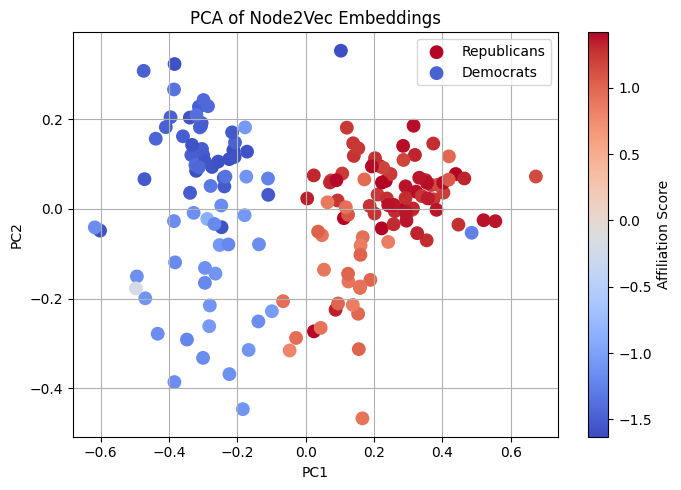

In [223]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(embedding_df.values)

# Merge with party + affiliation
pc_df = pd.DataFrame(reduced, columns=['PC1', 'PC2'], index=embedding_df.index)
df_data_indexed = df_data.set_index('current_twitter_name')
pc_df['affiliation_score'] = df_data_indexed['affiliation_score']
pc_df['party'] = df_data_indexed['party']

# Split by party
rep = pc_df[pc_df['party'] == 'R']
dem = pc_df[pc_df['party'] == 'D']

# 🔥 Shared color normalization (this is key)
norm = colors.Normalize(vmin=pc_df['affiliation_score'].min(), vmax=pc_df['affiliation_score'].max())
cmap = cm.get_cmap('coolwarm')

# Plotting
fig, ax = plt.subplots(figsize=(7, 5))  # NEW: create fig and ax together

# Scatter Republicans
scatter_rep = ax.scatter(
    rep['PC1'], rep['PC2'],
    c=cmap(norm(rep['affiliation_score'])),
    linewidths=1, s=80, label='Republicans' #, edgecolors='limegreen'
)

# Scatter Democrats
scatter_dem = ax.scatter(
    dem['PC1'], dem['PC2'],
    c=cmap(norm(dem['affiliation_score'])),
    linewidths=1, s=80, label='Democrats' #,edgecolors='deeppink'
)

# Create ScalarMappable and colorbar linked to it
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # don't actually need data here
fig.colorbar(sm, ax=ax, label='Affiliation Score')  # ✅ assign the Axes explicitly

# Final plot details
ax.set_title('PCA of Node2Vec Embeddings')
ax.legend()
ax.grid(True)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
fig.tight_layout()
plt.show()



In [224]:
# pc_df = pd.DataFrame(reduced, columns=['PC0', 'PC1'])
pc_df = pd.DataFrame(reduced, columns=['PC1', 'PC2'], index=embedding_df.index)

# pc_df['affiliation_score'] = df_data['affiliation_score'].values
# df_data['pca_affiliation_strength'] = pc_df['PC0']
df_data = df_data.set_index('current_twitter_name')  # if it's not already
df_data['pca_affiliation_strength'] = pc_df['PC2']   # or PC0, depending on what you're tracking
df_data = df_data.reset_index()  # optional, if you want the names back as a column

df_data


,current_twitter_name,party,complete_following,following,affiliation_score,pca_affiliation_strength
0,SpeakerRyan,R,"[DarrellIssa, WaysandMeansGOP, cathymcmorris, ...","[DarrellIssa, WaysandMeansGOP, RepKevinBrady, ...",1.406593,0.078021
1,SpeakerPelosi,D,"[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...","[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...",-1.479452,0.308211
2,michelebachmann,R,"[DavidLimbaugh, RedState, Heritage, ScottWalke...","[DavidLimbaugh, RedState, Heritage, ScottWalke...",1.219780,0.036385
3,dwstweets,D,"[donnabrazile, Eugene_Robinson, JaredEMoskowit...","[donnabrazile, Eugene_Robinson, JaredEMoskowit...",-1.479452,0.204680
4,EricCantor,R,"[EWErickson, foxnewspolitics, SpeakerBoehner, ...","[EWErickson, foxnewspolitics, SpeakerBoehner, ...",1.340659,0.023463
...,...,...,...,...,...,...
159,stabenow,D,"[SenStabenow, SenGaryPeters, gretchenwhitmer, ...","[SenStabenow, SenGaryPeters, gretchenwhitmer, ...",-1.164384,-0.386223
160,sen_joemanchin,D,"[SenatorSinema, lisamurkowski, WVGovernor, Sen...","[SenatorSinema, WVGovernor, SenCapito, SenJoni...",-1.041096,-0.228059
161,sendancoats,R,"[AttyAbdul, lisamurkowski, nkellyIN, marybschn...","[AttyAbdul, nkellyIN, marybschneider, camsavag...",1.010989,-0.144465
162,mcconnellpress,R,"[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...","[LeaderMcConnell, KYGOP, SenJohnThune, JamesCo...",0.912088,-0.467139


In [225]:
print("Spearman Corr PC1:", spearmanr(df_data['pca_affiliation_strength'], df_data['affiliation_score']))
print("Pearson Corr PC1:", pearsonr(df_data['pca_affiliation_strength'], df_data['affiliation_score']))



Spearman Corr PC1: SignificanceResult(statistic=-0.18477236495145372, pvalue=0.017856823608016156)
Pearson Corr PC1: PearsonRResult(statistic=-0.12598563853014427, pvalue=0.10795033643262185)


In [226]:
republican_df = df_data[df_data['party'] == 'R']
democratic_df = df_data[df_data['party'] == 'D']
# print("Spearman Corr PC1 Republican:", spearmanr(republican_df['pca_affiliation_strength'], republican_df['affiliation_score']))
print("Pearson Corr PC1 Republican:", pearsonr(republican_df['pca_affiliation_strength'], republican_df['affiliation_score']))
# print("Spearman Corr PC1 Democrat:", spearmanr(democratic_df['pca_affiliation_strength'], democratic_df['affiliation_score']))
print("Pearson Corr PC1 Democrat:", pearsonr(democratic_df['pca_affiliation_strength'], democratic_df['affiliation_score']))



Pearson Corr PC1 Republican: PearsonRResult(statistic=0.5771315555353549, pvalue=2.1228416479931157e-09)
Pearson Corr PC1 Democrat: PearsonRResult(statistic=-0.6428362848463409, pvalue=8.689345105969909e-10)


In [236]:
df_data.rename(columns={"affiliation_score": "Affiliation Score", "pca_affiliation_strength": "PC2"}, inplace=True)
republican_df = df_data[df_data['party'] == 'R']
democratic_df = df_data[df_data['party'] == 'D']

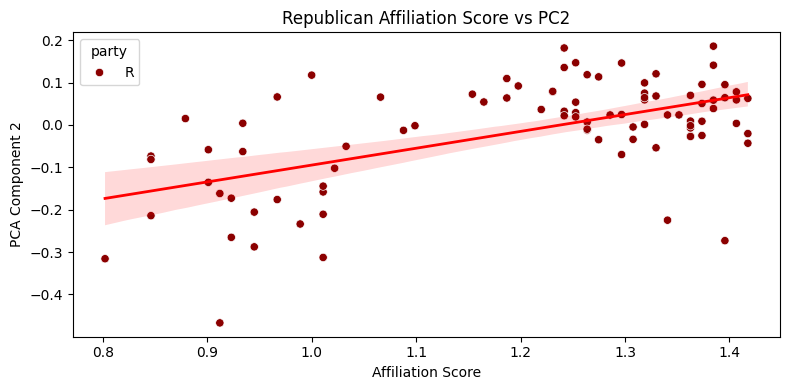

In [260]:
# df_data['pca_affiliation_strength'] = pc_df['PC0']
plt.figure(figsize=(8, 4))
sns.scatterplot(data=republican_df, x='Affiliation Score', y='PC2', hue='party',
    palette={'R': 'darkred', 'D': 'darkblue'})
sns.regplot(
    data=republican_df, 
    x='Affiliation Score', 
    y='PC2', 
    scatter=False,    # Don't replot points
    color='red',    # Line color
    line_kws={'linewidth': 2}  # Make the line a bit thicker
)
plt.title('Republican Affiliation Score vs PC2')
plt.xlabel('Affiliation Score')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()



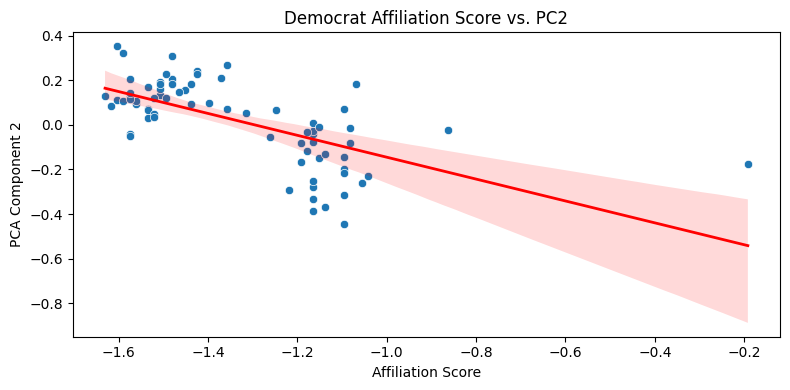

In [257]:
# df_data['pca_affiliation_strength'] = pc_df['PC0']
plt.figure(figsize=(8, 4))
sns.scatterplot(data=democratic_df, x='Affiliation Score', y='PC2')
sns.regplot(
    data=democratic_df, 
    x='Affiliation Score', 
    y='PC2', 
    scatter=False,    # Don't replot points
    color='red',    # Line color
    line_kws={'linewidth': 2}  # Make the line a bit thicker
)
# Add a title
plt.title('Democrat Affiliation Score vs. PC2')
plt.xlabel('Affiliation Score')
plt.ylabel('PCA Component 2')
# Optional: tighten layout and show
plt.tight_layout()
plt.show()


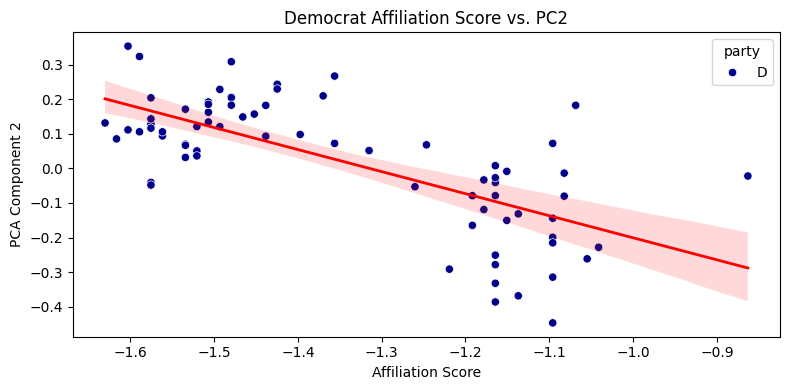

In [258]:
democratic_df_fake = democratic_df[democratic_df['Affiliation Score'] < -0.6]
# df_data['pca_affiliation_strength'] = pc_df['PC0']
plt.figure(figsize=(8, 4))
sns.scatterplot(data=democratic_df_fake, x='Affiliation Score', y='PC2', hue='party',
    palette={'R': 'darkred', 'D': 'darkblue'})
sns.regplot(
    data=democratic_df_fake, 
    x='Affiliation Score', 
    y='PC2', 
    scatter=False,    # Don't replot points
    color='red',    # Line color
    line_kws={'linewidth': 2}  # Make the line a bit thicker
)
# Add a title
plt.title('Democrat Affiliation Score vs. PC2')
plt.xlabel('Affiliation Score')
plt.ylabel('PCA Component 2')
# Optional: tighten layout and show
plt.tight_layout()
plt.show()

